In [ ]:
# Biblioteca para operações numéricas
import numpy as np

# Para Visualização
import matplotlib.pyplot as plt

# Para Redes Neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

In [ ]:
# Carregar a base CIFAR
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar valores para intervalo [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo", "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_test: {y_test.shape}")

Formato de X_train: (50000, 32, 32, 3)
Formato de y_train: (50000,)
Formato de X_test: (10000, 32, 32, 3)
Formato de y_test: (10000,)


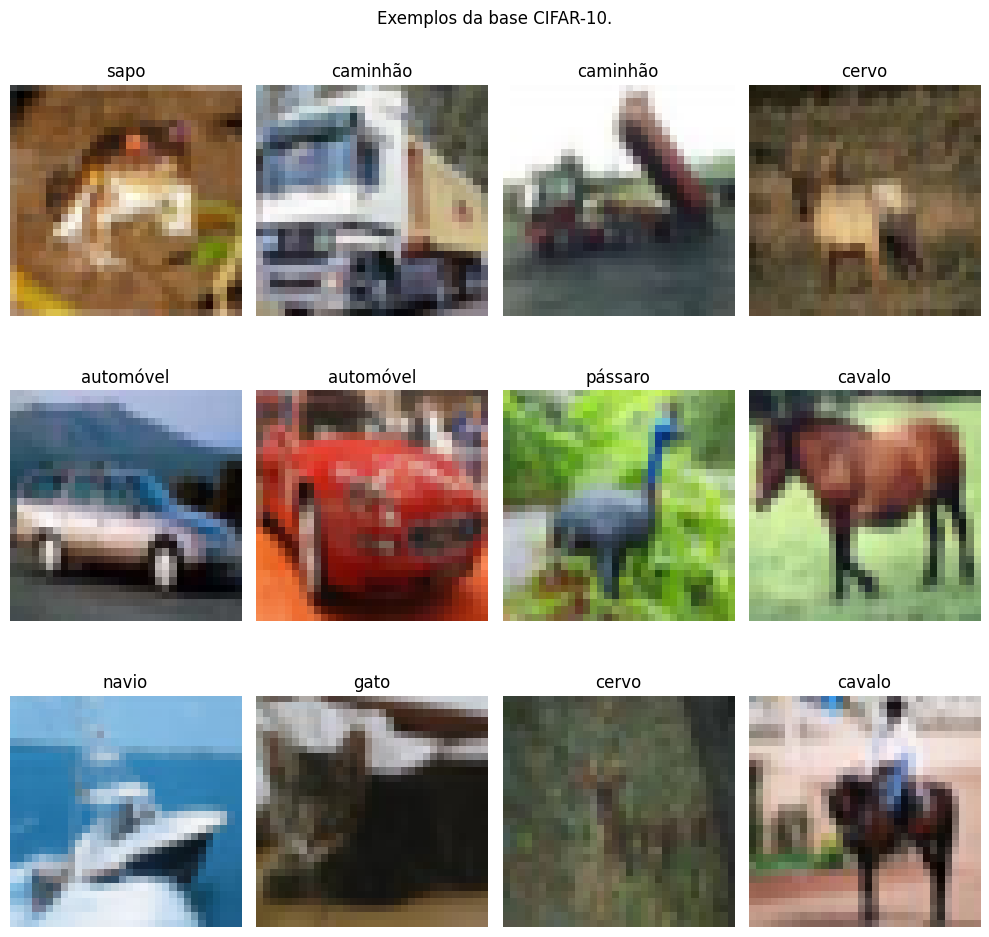

In [ ]:
plt.figure(figsize=(10,10))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Exemplos da base CIFAR-10.')
plt.tight_layout()
plt.show()

In [ ]:
from keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                          BatchNormalization, RandomFlip, RandomTranslation)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def bloco_conv(model, filtros, drop):
    model.add(Conv2D(filtros, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filtros, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(drop))

model = keras.Sequential()
model.add(Input(shape=(32, 32, 3)))

# Data augmentation (só atua no treino)
model.add(RandomFlip("horizontal"))
model.add(RandomTranslation(0.1, 0.1))

# Blocos convolucionais
bloco_conv(model, 32, 0.2)    # 32x32 -> 16x16
bloco_conv(model, 64, 0.3)    # 16x16 -> 8x8
bloco_conv(model, 128, 0.4)   # 8x8   -> 4x4

# Classificador
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=64,
    callbacks=callbacks
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.3940 - loss: 1.7706 - val_accuracy: 0.4538 - val_loss: 1.5566 - learning_rate: 0.0010
Epoch 2/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5584 - loss: 1.2392 - val_accuracy: 0.6166 - val_loss: 1.1175 - learning_rate: 0.0010
Epoch 3/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6223 - loss: 1.0627 - val_accuracy: 0.7124 - val_loss: 0.8264 - learning_rate: 0.0010
Epoch 4/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6684 - loss: 0.9504 - val_accuracy: 0.7088 - val_loss: 0.8647 - learning_rate: 0.0010
Epoch 5/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.7003 - loss: 0.8648 - val_accuracy: 0.7550 - val_loss: 0.6985 - learning_rate: 0.0010
Epoch 6/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7163 - loss: 0.8176 - val_accuracy: 0.7446 - val_loss: 0.7443 - learning_rate: 0.0010
Epoch 7/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7352 - l

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")
print(f"Loss no teste: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8964 - loss: 0.3265
Acurácia no conjunto de teste: 89.64%
Loss no teste: 0.3265


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


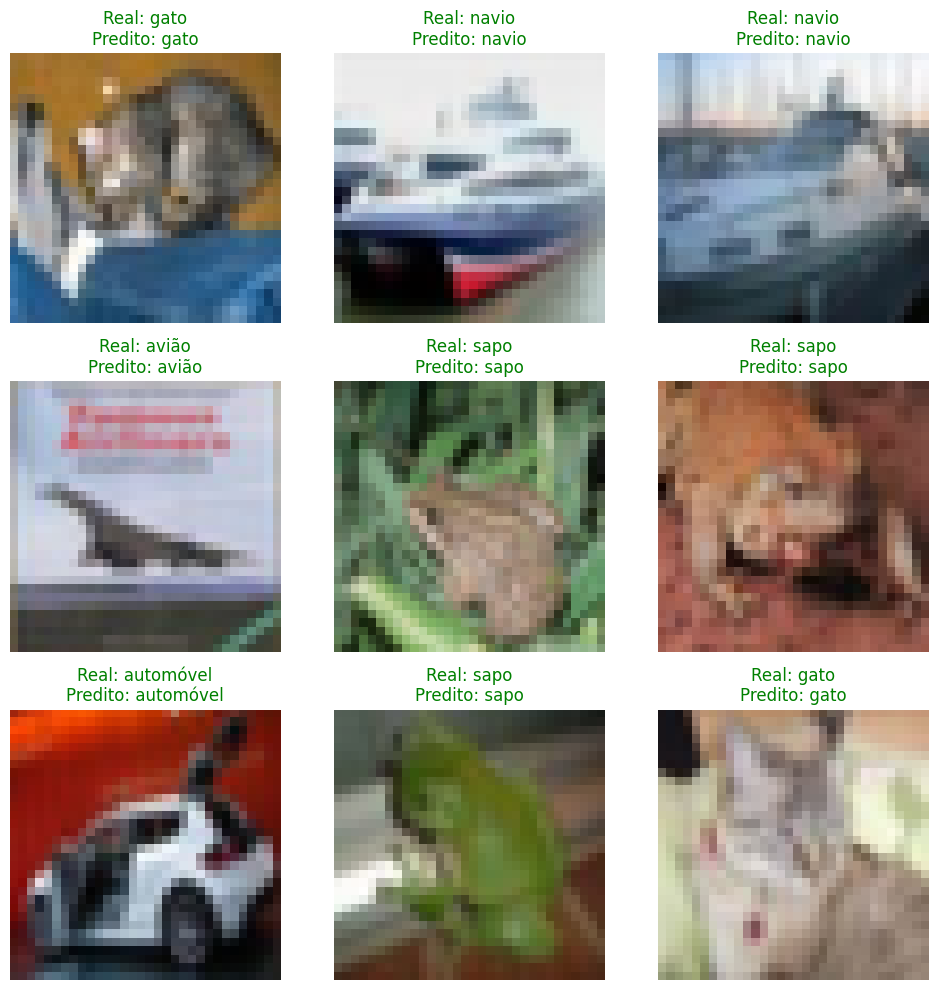

In [ ]:
pred_probs = model.predict(X_test[:9])

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    real_class = class_names[y_test[i]]
    pred_class = class_names[np.argmax(pred_probs[i])]
    cor = "green" if real_class == pred_class else "red"
    plt.title(f"Real: {real_class}\nPredito: {pred_class}", color=cor)
    plt.axis("off")

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.show()

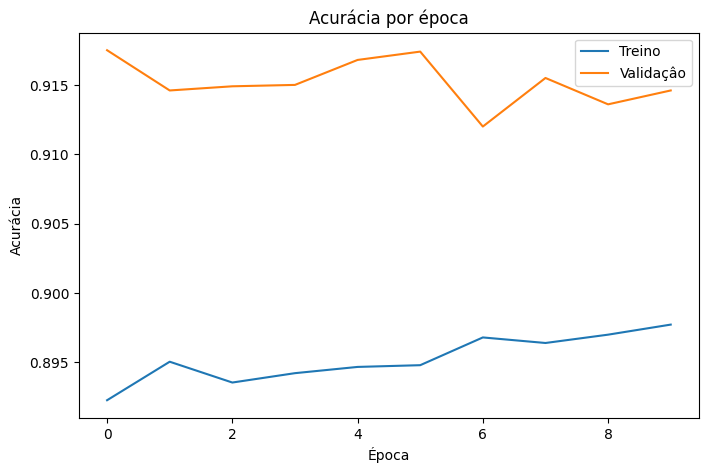

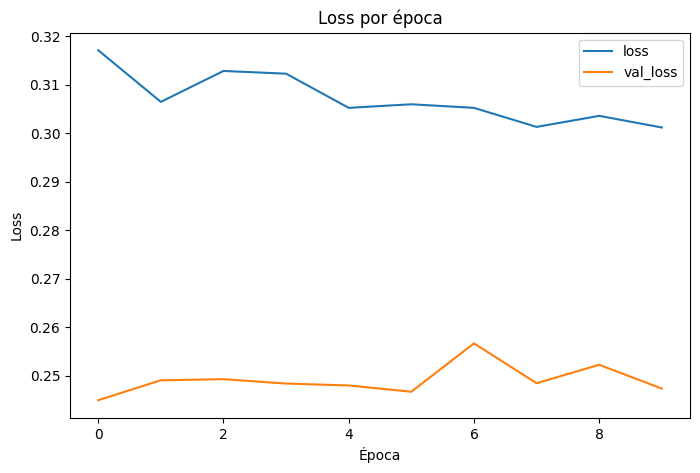

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validaçâo')
plt.title('Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()



plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()